# **1 Листок**

#1.1. (С использованием JupyterNotebook) Найти общее решение системы линейных уравнений
x1 + 5x2 − 2x3 = −7,

−3x1 + x2 + 9x3 − 5x4 = 9,

4x1 − 8x2 − x3 + 7x4 = 0.

In [1]:
import numpy as np
import scipy.linalg as la
from sympy import *
init_printing()

A = np.array([[1, 5, -2, 0], [-3, 1, 9, -5], [4, -8, -1, 7]])

b = np.array([-7, 9, 0]).reshape(3, 1)

A_b = np.hstack([A, b])

Matrix(A_b).rref()

⎛⎡1  0  0  8/7   -11/7⎤           ⎞
⎜⎢                    ⎥           ⎟
⎜⎢0  1  0  -2/7  -6/7 ⎥, (0, 1, 2)⎟
⎜⎢                    ⎥           ⎟
⎝⎣0  0  1  -1/7   4/7 ⎦           ⎠

**1.2** Дана система линейных уравнений:
\begin{cases}
5x_1 - x_2 + 5x_3 + 9x_4 - 2x_5 = -3,\\
3x_1 + 0x_2 + 6x_3 + 9x_4 - x_5 = 4,\\
2x_1 + 0x_2 + 4x_3 + 6x_4 - x_5 = 0.\\
\end{cases}
Требуется найти:\
а)rref(A∣b) (приведённый ступенчатый вид расширенной матрицы);\
б)общее решение системы линейных уравнений

In [7]:
from sympy import symbols, Matrix, linsolve, latex
from IPython.display import display, Math

# Переменные для красивого вывода
x1, x2, x3, x4, x5 = symbols('x1 x2 x3 x4 x5')
variables = [x1, x2, x3, x4, x5]

# Расширенная матрица (A|b)
A_b = Matrix([
    [5, -1, 5, 9, -2, -3],
    [3,  0, 6, 9, -1,  4],
    [2,  0, 4, 6, -1,  0]
])

# rref матрицы и индексы базисных столбцов
rref_matrix, pivot_cols = A_b.rref()

# Вывод пункта а)
print("a) rref(A|b):")
display(rref_matrix)

# Форматируем красивый вывод в виде формулы
solution = list(linsolve(A_b, variables))[0]
sol_latex = "; ".join([latex(comp) for comp in solution])
display(Math(f"\\text{{б) }} x = ({sol_latex})"))

a) rref(A|b):


⎡1  0  2  3  0  4⎤
⎢                ⎥
⎢0  1  5  6  0  7⎥
⎢                ⎥
⎣0  0  0  0  1  8⎦

<IPython.core.display.Math object>

**1.3** Дана система линейных уравнений:
$$\begin{cases}
32x + 97y + 90z + 48u = 47, \\
35x + 84y + 91z + 54u = 40, \\
17x + 18y + 21z + 13u = 37.
\end{cases}$$
Требуется:
1) Объяснить, почему переменную $y$ можно представить как функцию от $x$ вида $y = a + bx$, где $a$ и $b$ — константы, зависящие только от коэффициентов исходной системы;
2) Найти константу $a$;
3) Найти константу $b$.

1. Если рассматривать столбцы с коэффициентами при переменных z и u, мы получим 
$$\begin{pmatrix}
90 & 48 \\
91 & 54 \\
21 & 13
\end{pmatrix}$$
Ранг такой матрицы $\le 2$, $\Rightarrow$ строки данной матрицы линейно зависимы $\Rightarrow$ существует ненулевой вектор-строка 
$$\begin{pmatrix}
a & b & c 
\end{pmatrix}$$
такой, что полностью обнуляет коэффициенты при z и u. Исходя из этого переменную y можно будет выразить через x, при условии ненулевого коэффициента при y.


In [12]:
from sympy import symbols, Eq, solve, Poly
from IPython.display import display, Math

# Переменные для красивого вывода
x, y, z, u = symbols('x y z u')

# Уравнения системы
eq1 = Eq(32*x + 97*y + 90*z + 48*u, 47)
eq2 = Eq(35*x + 84*y + 91*z + 54*u, 40)
eq3 = Eq(17*x + 18*y + 21*z + 13*u, 37)

# Выражаем y, z, u через x
sol = solve([eq1, eq2, eq3], (y, z, u))
y_expr = sol[y]

# Представляем y(x) в виде многочлена от x для извлечения коэффициентов
poly_y = Poly(y_expr, x)
b = poly_y.coeff_monomial(x)  # коэффициент при x^1
a = poly_y.coeff_monomial(1)  # свободный член (x^0)

# Красивый вывод формулы
display(Math(f"y = {a} + ({b})x"))

<IPython.core.display.Math object>

**1.4** Выполнить действия:
$$\begin{pmatrix}
3 & 0 & 2 \\
0 & 1 & 3 \\
2 & 2 & 0 \\
0 & 1 & 0
\end{pmatrix}
\cdot
\begin{pmatrix}
1 & 2 & -1 & 2 \\
-2 & -1 & 1 & 2 \\
2 & 1 & 1 & 2
\end{pmatrix}
+
\begin{pmatrix}
0 & -4 & 6 & 1 \\
2 & 2 & -5 & -2 \\
2 & -2 & 6 & 4 \\
1 & 3 & 0 & 1
\end{pmatrix}$$

In [13]:
from sympy import Matrix, latex
from IPython.display import display, Math

# Задаем исходные матрицы
A = Matrix([
    [3, 0, 2],
    [0, 1, 3],
    [2, 2, 0],
    [0, 1, 0]
])

B = Matrix([
    [ 1,  2, -1, 2],
    [-2, -1,  1, 2],
    [ 2,  1,  1, 2]
])

C = Matrix([
    [0, -4,  6,  1],
    [2,  2, -5, -2],
    [2, -2,  6,  4],
    [1,  3,  0,  1]
])

# Выполняем действия
result = A * B + C

# Красивый вывод результата
display(Math(f"{latex(A)} \\cdot {latex(B)} + {latex(C)} = {latex(result)}"))

<IPython.core.display.Math object>

**1.5** Найдите определители порядка $n$, элементы которого заданы условием:

а) $a_{ij} = \min(i, j)$;  
б) $a_{ij} = \max(i, j)$;  
в)* $a_{ij} = |i - j|$.

### **Аналитическое решение**

#### **а) $a_{ij} = \min(i, j)$**
Запишем матрицу $A$:
$$A = \begin{pmatrix}
1 & 1 & 1 & \dots & 1 \\
1 & 2 & 2 & \dots & 2 \\
1 & 2 & 3 & \dots & 3 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & 2 & 3 & \dots & n
\end{pmatrix}$$

Выполним элементарные преобразования строк: из каждой $k$-й строки вычтем предыдущую $(k-1)$-ю строку последовательно снизу вверх.

Матрица приводится к верхнетреугольному виду с единицами на главной диагонали:
$$\det(A) = \begin{vmatrix}
1 & 1 & 1 & \dots & 1 \\
0 & 1 & 1 & \dots & 1 \\
0 & 0 & 1 & \dots & 1 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \dots & 1
\end{vmatrix} = 1 \cdot 1 \cdots 1 = \mathbf{1}$$

$$\mathbf{\det(A) = 1}$$

---

#### **б) $a_{ij} = \max(i, j)$**
Запишем матрицу $B$:
$$B = \begin{pmatrix}
1 & 2 & 3 & \dots & n \\
2 & 2 & 3 & \dots & n \\
3 & 3 & 3 & \dots & n \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
n & n & n & \dots & n
\end{pmatrix}$$

Вычтем из каждой $k$-й строки следующую $(k+1)$-ю строку сверху вниз.

Получаем матрицу:
$$\det(B) = \begin{vmatrix}
-1 & 0 & 0 & \dots & 0 & 0 \\
-1 & -1 & 0 & \dots & 0 & 0 \\
\vdots & \vdots & \ddots & & \vdots & \vdots \\
-1 & -1 & -1 & \dots & -1 & 0 \\
n & n & n & \dots & n & n
\end{vmatrix}$$

В последнем столбце остался только один ненулевой элемент — $b_{nn} = n$. Разложим определитель по последнему столбцу:
$$\det(B) = (-1)^{n+n} \cdot n \cdot M_{nn} = n \cdot M_{nn}$$
Минор $M_{nn}$ — это нижнетреугольный определитель порядка $(n-1)$, на главной диагонали которого стоят $(-1)$:
$$M_{nn} = \begin{vmatrix}
-1 & 0 & \dots & 0 \\
-1 & -1 & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
-1 & -1 & \dots & -1
\end{vmatrix} = (-1)^{n-1}$$

Следовательно:
$$\mathbf{\det(B) = (-1)^{n-1} n}$$

---

#### **в)* $a_{ij} = |i - j|$**
Запишем матрицу $C$:
$$C = \begin{pmatrix}
0 & 1 & 2 & 3 & \dots & n-1 \\
1 & 0 & 1 & 2 & \dots & n-2 \\
2 & 1 & 0 & 1 & \dots & n-3 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
n-1 & n-2 & n-3 & n-4 & \dots & 0
\end{pmatrix}$$

1. При $n = 1$: $\det(C) = |0| = 0$.
2. При $n \ge 2$:  
   Выполним последовательное вычитание строк: из каждой строки, начиная с последней, вычтем предыдущую. Получим 1 до главной диагонали, -1 на и после главной диагонали.
   
   Затем повторим эту же операцию ещё раз. После останутся 2, на каждой строке под главной диаганалью получатся 2 (всего n-2 двоек), остальные 1 и -1 занулятся.
   
   Последовательно раскладывая определитель по этим строкам, выносится множитель $2^{n-2}$, а оставшийся минор размера $2 \times 2$ даёт:
   $$\begin{vmatrix} 0 & n-1 \\ 1 & -1 \end{vmatrix} = -(n-1)$$

С учётом знаков перестановок и разложений получаем:
$$\mathbf{\det(C) = (-1)^{n-1} (n - 1) 2^{n - 2}} \quad (n \ge 1)$$

In [15]:
from sympy import Matrix, symbols, Function, init_printing
from IPython.display import display, Math

# Функция для вычисления определителей порядка n
def solve_1_5(n):
    # а) a_ij = min(i, j)
    A = Matrix(n, n, lambda i, j: min(i + 1, j + 1))
    
    # б) a_ij = max(i, j)
    B = Matrix(n, n, lambda i, j: max(i + 1, j + 1))
    
    # в) a_ij = |i - j|
    C = Matrix(n, n, lambda i, j: abs(i - j))
    
    return A.det(), B.det(), C.det()

# Проверим формулы для нескольких значений n (от 1 до 5)
print("Проверка вычислением для n от 1 до 5:")
for n in range(1, 6):
    det_a, det_b, det_c = solve_1_5(n)
    print(f"n = {n}: det(A) = {det_a}, det(B) = {det_b}, det(C) = {det_c}")

# Красивый вывод общих аналитических формул
display(Math(r"\text{Ответ:}"))
display(Math(r"\text{а) } \det(A) = 1"))
display(Math(r"\text{б) } \det(B) = (-1)^{n-1} n"))
display(Math(r"\text{в) } \det(C) = (-1)^{n-1} (n - 1) 2^{n - 2}"))

Проверка вычислением для n от 1 до 5:
n = 1: det(A) = 1, det(B) = 1, det(C) = 0
n = 2: det(A) = 1, det(B) = -2, det(C) = -1
n = 3: det(A) = 1, det(B) = 3, det(C) = 4
n = 4: det(A) = 1, det(B) = -4, det(C) = -12
n = 5: det(A) = 1, det(B) = 5, det(C) = 32


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**1.6** Найдите наибольшее значение определителя шестого порядка, составленного из чисел $-1$, $0$ и $1$. (Можно перебором).

In [26]:
import numpy as np
from sympy import Matrix, latex
from IPython.display import display, Math

# 1. Алгоритм локального поиска (перебор с улучшением)
def find_max_det_order_6(num_restarts=30):
    best_det = 0
    best_matrix = None
    
    for _ in range(num_restarts):
        # Начинаем со случайной матрицы из элементов {-1, 1}
        A = np.random.choice([-1, 1], size=(6, 6))
        current_det = abs(int(round(np.linalg.det(A))))
        
        # Локальный перебор (инвертируем элементы по одному)
        improved = True
        while improved:
            improved = False
            for i in range(6):
                for j in range(6):
                    A[i, j] = -A[i, j]
                    d = abs(int(round(np.linalg.det(A))))
                    if d > current_det:
                        current_det = d
                        improved = True
                    else:
                        A[i, j] = -A[i, j]  # откат
                        
        if current_det > best_det:
            best_det = current_det
            best_matrix = A.copy()
                
    return best_det, Matrix(best_matrix)

# 2. Поиск максимального определителя
max_det, max_matrix = find_max_det_order_6()

# 3. Вывод результатов
display(Math(r"\text{Пример матрицы с максимальным определителем } A_{\max}:"))
display(Math(f"A_{{\\max}} = {latex(max_matrix)}"))
display(Math(f"\\det(A_{{\\max}}) = {max_det}"))

print(f"Ответ: Наибольшее значение определителя шестого порядка равно {max_det}.")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Ответ: Наибольшее значение определителя шестого порядка равно 160.


**1.7** Матрица $A = (a_{i,j})$ имеет размер $n \times n$, где $n = 80000$. Известно, что её диагональные элементы образуют арифметическую прогрессию с начальным элементом $a_{1,1} = 0{,}99$ и конечным элементом $a_{n,n} = 1{,}01$. Также известно, что все элементы матрицы $A$, расположенные вне главной диагонали, равны нулю за исключением двух элементов: $a_{1,2} = 0{,}57$ и $a_{2,1} = 0{,}03$.  
Найдите:
1) Определитель матрицы $A$;
2) След матрицы, обратной к $A$ ($\operatorname{tr}(A^{-1})$).

In [27]:
import numpy as np

# Параметры задачи
n = 80000
a11 = 0.99
ann = 1.01
a12 = 0.57
a21 = 0.03

# 1. Диагональные элементы образуют арифметическую прогрессию
diag = np.linspace(a11, ann, n)
a22 = diag[1]

# 2. Определитель матрицы A
# det(M2) для верхнего блока 2x2
det_M2 = a11 * a22 - a12 * a21

# Произведение элементов со 3-го по n-й (через сумму логарифмов для точности)
log_prod_3_to_n = np.sum(np.log(diag[2:]))
det_A = det_M2 * np.exp(log_prod_3_to_n)

# 3. След обратной матрицы tr(A^{-1})
# След блока (M2)^{-1}
tr_inv_M2 = (a11 + a22) / det_M2

# Сумма обратных элементов диагонали с 3-го по n-й
sum_inv_3_to_n = np.sum(1.0 / diag[2:])
trace_inv_A = tr_inv_M2 + sum_inv_3_to_n

# Вывод результатов
print(f"Ответ: 1) {det_A:.3f}; 2) {trace_inv_A:.3f}.")

Ответ: 1) 0.259; 2) 80002.703.


**1.8** Матрица $A = (a_{i,j})$ имеет размер $n \times n$, где $n = 43000$. Известно, что:
1) Диагональные элементы образуют геометрическую прогрессию с начальным элементом $a_{1,1} = 1$ и конечным элементом $a_{n,n} = 1{,}07$;
2) Элементы первой строки образуют арифметическую прогрессию с конечным элементом $a_{1,n} = 1{,}10$;
3) Все элементы матрицы $A$, расположенные вне главной диагонали и вне первой строки, равны нулю.

Найдите обратную матрицу $B = A^{-1}$ и укажите в ответе:
1) Наименьший элемент матрицы $B$;
2) Сумму элементов матрицы $B$.

In [28]:
import numpy as np

# Параметры задачи
n = 43000
a11 = 1.0
ann = 1.07
a1n = 1.10

# 1. Диагональ A: геометрическая прогрессия от 1.0 до 1.07
# d_k = q^(k-1), где q = (ann / a11)**(1 / (n - 1))
q = (ann / a11) ** (1.0 / (n - 1))
d = a11 * (q ** np.arange(n))

# 2. Первая строка A: арифметическая прогрессия от 1.0 до 1.10
r = np.linspace(a11, a1n, n)

# 3. Элементы обратной матрицы B:
# Первая строка: b[0, 0] = 1, b[0, j] = -r[j] / d[j] для j >= 1
b_first_row = -r / d
b_first_row[0] = 1.0 / d[0]  # b[0, 0] = 1.0

# Диагональ: b[k, k] = 1 / d[k]
b_diag = 1.0 / d

# 4. Наименьший элемент матрицы B
# (среди всех элементов матрицы B: отрицательные только в первой строке)
min_elem = np.min(b_first_row)

# 5. Сумма всех элементов матрицы B
# Вся сумма складывается из первой строки и элементов диагонали со 2-го по n-й
total_sum = np.sum(b_first_row) + np.sum(b_diag[1:])

# Вывод результатов
print(f"Ответ: 1) {min_elem:.3f}; 2) {total_sum:.1f}.")

Ответ: 1) -1.028; 2) -2054.4.


**1.9** Даны матрицы:
$$I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}, \quad A = \begin{pmatrix} 7\gamma & 14\gamma \\ 9\gamma & 1\gamma \end{pmatrix}, \quad \text{где } \gamma = 0{,}057$$

Пусть $S_{m,n} = \sum_{i=m}^n A^i, \quad B_m = (I - A)^{-1} A^m$.  
Требуется найти:
1) Наибольший элемент матрицы $S = S_{4,70}$;
2) Наибольший элемент матрицы $B = B_4$;
3) Наименьшее $k$, такое, что при любом $n > k$ наибольший элемент матрицы $S_{k,n}$ меньше $0{,}0002$.

In [29]:
import numpy as np

# 1. Задаем исходные данные
gamma = 0.057
I = np.eye(2)
A = gamma * np.array([
    [7.0, 14.0],
    [9.0,  1.0]
])

# Обратная матрица (I - A)^(-1)
inv_I_minus_A = np.linalg.inv(I - A)

# 2. Пункт 1: S_{4, 70} = \sum_{i=4}^{70} A^i = (I - A)^(-1) * (A^4 - A^71)
A4 = np.linalg.matrix_power(A, 4)
A71 = np.linalg.matrix_power(A, 71)
S_4_70 = inv_I_minus_A @ (A4 - A71)
ans1 = np.max(S_4_70)

# 3. Пункт 2: B_4 = (I - A)^(-1) * A^4
B4 = inv_I_minus_A @ A4
ans2 = np.max(B4)

# 4. Пункт 3: Поиск наименьшего k, такого что max(B_k) < 0.0002
# Так как S_{k, n} монотонно возрастает по n к B_k, условие выполнено для всех n > k тогда и только тогда, когда max(B_k) < 0.0002
threshold = 0.0002
k = 1
A_k = A.copy()

while True:
    B_k = inv_I_minus_A @ A_k
    if np.max(B_k) < threshold:
        ans3 = k
        break
    A_k = A_k @ A
    k += 1

# Вывод результатов
print(f"Ответ: 1) {ans1:.6f}; 2) {ans2:.6f}; 3) {ans3}.")

Ответ: 1) 3.609679; 2) 3.611175; 3) 89.


# **2 Листок**

**2.1** Представьте в алгебраической, тригонометрической и показательной формах следующие комплексные выражения: \
a) $\dfrac{(5 + i)(7 - 6i)}{3 + i}$; \
b) $\dfrac{(1 + i)^5}{(1 - i)^3}$; \
c) $\dfrac{(-1 + i\sqrt{3})^{15}}{(1 - i)^{20}} + \dfrac{(-1 - i\sqrt{3})^{15}}{(1 + i)^{20}}$.

In [2]:
from sympy import I, sqrt, Rational, pi, exp, cos, sin, re, im, arg, Abs, latex
from IPython.display import display, Math

# 1. Задание выражений
z_a = ((5 + I)*(7 - 6*I)) / (3 + I)
z_b = ((1 + I)**5) / ((1 - I)**3)
z_c = ((-1 + I*sqrt(3))**15)/((1 - I)**20) + ((-1 - I*sqrt(3))**15)/((1 + I)**20)

# 2. Функция для вывода трех форм числа
def show_forms(name, z):
    # Перевод в алгебраическую форму
    z_alg = z.simplify()

    # Модуль комплексного числа
    r = Abs(z_alg)

    # Аргумент комплексного числа
    phi = arg(z_alg)

    # Вывод всех необходимых форм
    display(Math(f"\\mathbf{{{name}}}:"))
    display(Math(r"\text{Алгебраическая: } " + latex(z_alg)))
    display(Math(r"\text{Тригонометрическая: } " + f"{latex(r)} \\left(\\cos\\left({latex(phi)}\\right) + i\\sin\\left({latex(phi)}\\right)\\right)"))
    display(Math(r"\text{Показательная: } " + f"{latex(r)} e^{{i \\left({latex(phi)}\\right)}}"))

# 3. Вывод результатов
show_forms("a", z_a)
show_forms("b", z_b)
show_forms("c", z_c)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**2.2** Решите уравнение и изобразите множество решений на комплексной плоскости:
$$z^8 = 1 + i$$

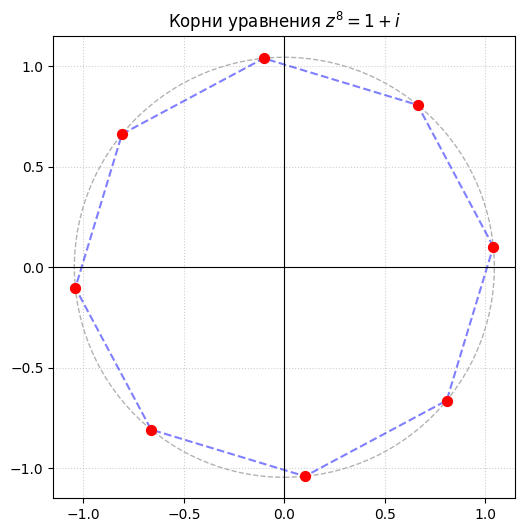

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Вычисление корней уравнения z^8 = 1 + i

# Правая часть уравнения
w = 1 + 1j

# Вычисление модуля
r = np.abs(w)**(1/8)

# Вычисление аргумента (угол наклона)
phi = np.angle(w)

# Вычисление всех корней уравнения
roots = [r * np.exp(1j * (phi + 2 * np.pi * k) / 8) for k in range(8)]

# 2. Построение на комплексной плоскости
plt.figure(figsize=(6, 6))
circle = plt.Circle((0, 0), r, color='gray', fill=False, linestyle='--', alpha=0.6)
plt.gca().add_patch(circle)

# Точки корней и соединяющий многоугольник
x_vals = [z.real for z in roots] + [roots[0].real]
y_vals = [z.imag for z in roots] + [roots[0].imag]
plt.plot(x_vals, y_vals, 'b--', alpha=0.5)
plt.scatter([z.real for z in roots], [z.imag for z in roots], color='red', s=50, zorder=5)

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.6)
plt.gca().set_aspect('equal')
plt.title(r'Корни уравнения $z^8 = 1 + i$')
plt.show()

**2.3** Вычислите (над полем $\mathbb{C}$) и изобразите на комплексной плоскости: \
a) $\sqrt[8]{1}$; \
b) $\sqrt[4]{-\dfrac{18}{1 + i\sqrt{3}}}$; \
c) $\sqrt[3]{\dfrac{1 - 5i}{1 + i} - 5\dfrac{1 + 2i}{2 - i} + 11}$; \
d) $\sqrt[9]{1 - i}$.

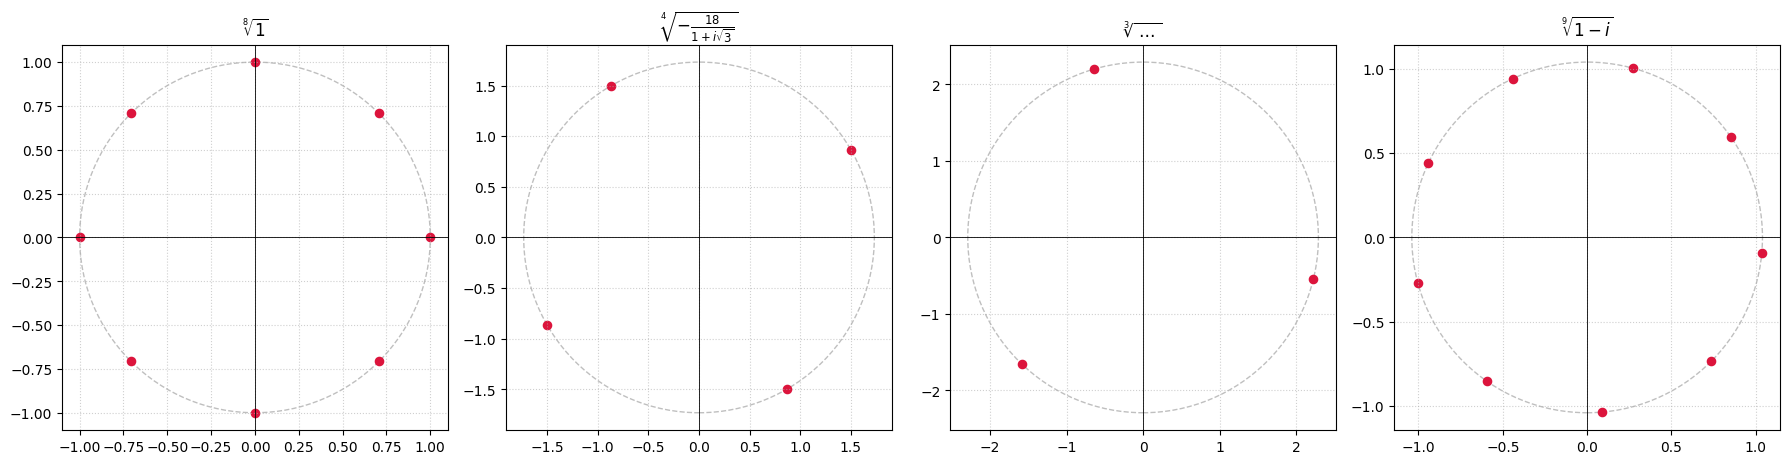

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Подкоренные комплексные числа (задаем их в виде (число, степень корня, LaTeX-строка для отображения))
nums = [
    (1 + 0j, 8, r"\sqrt[8]{1}"),
    (-18 / (1 + 1j * np.sqrt(3)), 4, r"\sqrt[4]{-\frac{18}{1 + i\sqrt{3}}}"),
    ((1 - 5j)/(1 + 1j) - 5*(1 + 2j)/(2 - 1j) + 11, 3, r"\sqrt[3]{\dots}"),
    (1 - 1j, 9, r"\sqrt[9]{1 - i}")
]

# 2. Отрисовка корней
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (w, n, title) in zip(axes, nums):
    # Вычисление модуля и аргумента
    r = np.abs(w)**(1/n)
    phi = np.angle(w)

    # Вычисление корней
    roots = [r * np.exp(1j * (phi + 2 * np.pi * k) / n) for k in range(n)]
    
    # Отрисовка круга и корней
    circle = plt.Circle((0, 0), r, color='gray', fill=False, linestyle='--', alpha=0.5)
    ax.add_patch(circle)
    ax.scatter([z.real for z in roots], [z.imag for z in roots], color='crimson', s=35)
    ax.axhline(0, color='black', lw=0.6)
    ax.axvline(0, color='black', lw=0.6)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_aspect('equal')
    ax.set_title(f"${title}$")

plt.tight_layout()
plt.show()

**2.4** Изобразите на комплексной плоскости множество точек, удовлетворяющих условию: \
a) $|z - i| + |z + i| < 4$; \
b) $\operatorname{Re}(z(1 - i)) < \sqrt{2}$; \
c) $|z + 1| = |z + i| = |z - i|$;\
d) $0 < \arg\left(\dfrac{i - z}{z + i}\right) < \dfrac{\pi}{2}$; \
e) $-\dfrac{2\pi}{3} \le \arg\left(\dfrac{2 - iz}{z + 3i}\right) \le -\dfrac{5\pi}{6}$; \
f) $-\dfrac{2\pi}{3} \le \arg\left(\dfrac{3 - z}{z + i}\right) \le -\dfrac{\pi}{3}$.

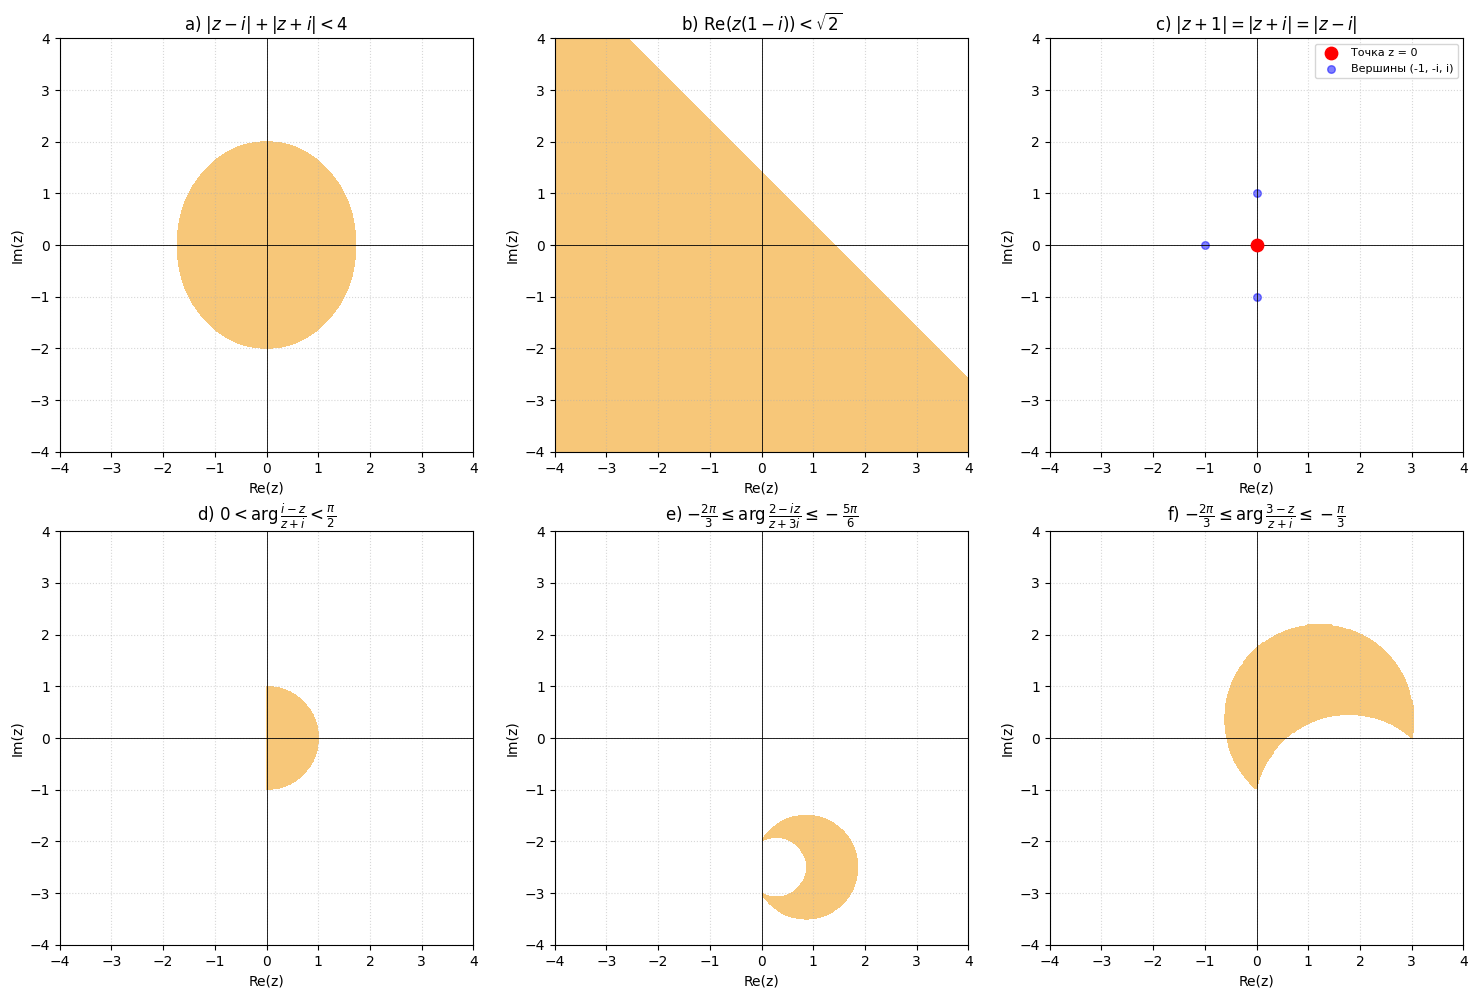

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Задаем сетку комплексной плоскости
x = np.linspace(-4, 4, 400)
y = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# 2. Вычисляем условия для всех пунктов
# a) Эллипс
cond_a = np.abs(Z - 1j) + np.abs(Z + 1j) < 4

# b) Полуплоскость
cond_b = np.real(Z * (1 - 1j)) < np.sqrt(2)

# d) Угловой сектор 0 < arg < pi/2
frac_d = (1j - Z) / (Z + 1j)
arg_d = np.angle(frac_d)
cond_d = (arg_d > 0) & (arg_d < np.pi / 2)

# e) Угловой сектор: -5pi/6 <= arg <= -2pi/3
frac_e = (2 - 1j * Z) / (Z + 3j)
arg_e = np.angle(frac_e)
cond_e = (arg_e >= -5 * np.pi / 6) & (arg_e <= -2 * np.pi / 3)

# f) Угловой сектор: -2pi/3 <= arg <= -pi/3
frac_f = (3 - Z) / (Z + 1j)
arg_f = np.angle(frac_f)
cond_f = (arg_f >= -2 * np.pi / 3) & (arg_f <= -np.pi / 3)

# 3. Построение всех 6 графиков на сетке 2x3
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# a
axes[0, 0].contourf(X, Y, cond_a, levels=[0.5, 1], colors=['#F5B041'], alpha=0.7)
axes[0, 0].set_title(r"a) $|z - i| + |z + i| < 4$")

# b
axes[0, 1].contourf(X, Y, cond_b, levels=[0.5, 1], colors=['#F5B041'], alpha=0.7)
axes[0, 1].set_title(r"b) $\mathrm{Re}(z(1-i)) < \sqrt{2}$")

# c (Особый случай - точка z = 0)
axes[0, 2].scatter([0], [0], color='red', s=80, zorder=5, label='Точка z = 0')
axes[0, 2].scatter([-1, 0, 0], [0, -1, 1], color='blue', s=30, alpha=0.5, label='Вершины (-1, -i, i)')
axes[0, 2].set_title(r"c) $|z+1|=|z+i|=|z-i|$")
axes[0, 2].legend(loc='upper right', fontsize=8)

# d
axes[1, 0].contourf(X, Y, cond_d, levels=[0.5, 1], colors=['#F5B041'], alpha=0.7)
axes[1, 0].set_title(r"d) $0 < \arg \frac{i-z}{z+i} < \frac{\pi}{2}$")

# e (заменено \le на \leq)
axes[1, 1].contourf(X, Y, cond_e, levels=[0.5, 1], colors=['#F5B041'], alpha=0.7)
axes[1, 1].set_title(r"e) $-\frac{2\pi}{3} \leq \arg \frac{2-iz}{z+3i} \leq -\frac{5\pi}{6}$")

# f (заменено \le на \leq)
axes[1, 2].contourf(X, Y, cond_f, levels=[0.5, 1], colors=['#F5B041'], alpha=0.7)
axes[1, 2].set_title(r"f) $-\frac{2\pi}{3} \leq \arg \frac{3-z}{z+i} \leq -\frac{\pi}{3}$")

# Оформление для всех осей
for ax in axes.flat:
    ax.axhline(0, color='black', lw=0.6)
    ax.axvline(0, color='black', lw=0.6)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('Re(z)')
    ax.set_ylabel('Im(z)')

plt.tight_layout()
plt.show()

**2.5\*** Пусть $A$ и $C$ — действительные, а $B$ — комплексная постоянная, причём $AC < |B|^2$. Покажите, что уравнение $A|z|^2 + \bar{B}z + B\bar{z} + C = 0$ ($A > 0$) является уравнением окружности, а также найдите центр этой окружности и её радиус.

In [5]:
from sympy import symbols, Abs, sqrt, latex
from IPython.display import display, Math

# 1. Параметры уравнения окружности в комплексной форме
# A*|z|^2 + B_conj*z + B*z_conj + C = 0 <=> |z - z0|^2 = R^2
A, C = symbols('A C', real=True, positive=True)

# 2. Аналитическое выражение центра и радиуса
z0_expr = r"-\frac{B}{A}"
R_expr = r"\frac{\sqrt{|B|^2 - AC}}{A}"

# 3. Вывод результатов
display(Math(r"\text{Уравнение сводится к виду: } \left|z - \left(-\frac{B}{A}\right)\right|^2 = \frac{|B|^2 - AC}{A^2}"))
display(Math(r"\text{Центр окружности } z_0: " + z0_expr))
display(Math(r"\text{Радиус окружности } R: " + R_expr))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**2.6** Для многочлена $p(x) = x^{11} + x^{10} + x^8 - 2x^7 - x^5 + x^4 + 2x^2 + 2x + 2$ найдите все его 11 корней $z_1, \dots, z_{11} \in \mathbb{C}$. В ответе укажите:
1) сумму модулей $|z_1| + \dots + |z_{11}|$;
2) действительную часть корня, у которого эта действительная часть максимальна.

In [6]:
import numpy as np

# 1. Коэффициенты полинома от старшей степени к младшей
coeffs = [1, 1, 0, 1, -2, 0, -1, 1, 0, 2, 2, 2]

# 2. Поиск корней
roots = np.roots(coeffs)

# 3. Вычисление требуемых величин
sum_moduli = np.sum(np.abs(roots))
max_real_part = np.max(np.real(roots))

# 4. Вывод ответов
print(f"Ответ: 1) Сумма модулей корней = {sum_moduli:.5f}")
print(f"       2) Максимальная действительная часть = {max_real_part:.5f}")

Ответ: 1) Сумма модулей корней = 11.97338
       2) Максимальная действительная часть = 1.08060


**2.7** Обобщение биномиальных коэффициентов: $C_z^w = \dfrac{\Gamma(z + 1)}{\Gamma(w + 1)\Gamma(z - w + 1)}$. \
a) Найдите $C_{1+i}^{1-i}$; \
b) Найдите $\operatorname{Arg}(C_{1+i}^{1-i})$; \
c) Постройте линии уровня $\operatorname{Arg}[C_z^{1/z} = \text{const}]$, где $z = x + iy$.

Ответ a): 4.36745 + 4.85163i
Ответ b): 0.837869 (48.0064°)


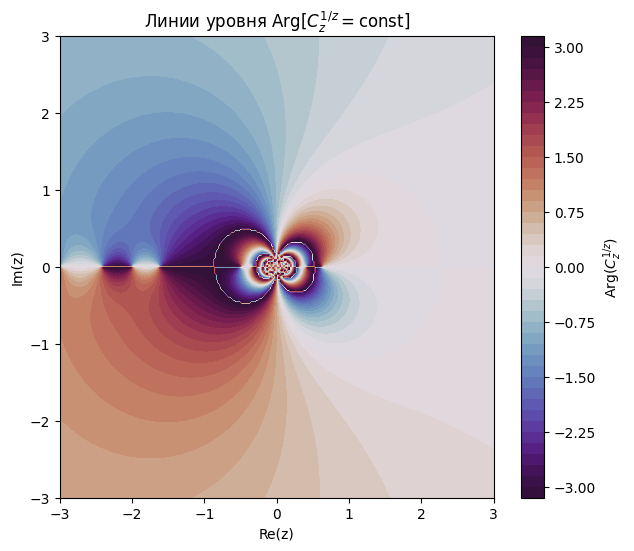

In [7]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

# 1. Пункты a) и b): Вычисление C_{1+i}^{1-i}
z_val = 1 + 1j
w_val = 1 - 1j

C_val = sp.gamma(z_val + 1) / (sp.gamma(w_val + 1) * sp.gamma(z_val - w_val + 1))
arg_C_rad = np.angle(C_val)
arg_C_deg = np.rad2deg(arg_C_rad)

print(f"Ответ a): {C_val.real:.5f} + {C_val.imag:.5f}i")
print(f"Ответ b): {arg_C_rad:.6f} ({arg_C_deg:.4f}°)")

# 2. Пункт c): Линии уровня Arg[C_z^{1/z}]
x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# Вычисление биномиального символа на сетке
W = 1.0 / Z
C_grid = sp.gamma(Z + 1) / (sp.gamma(W + 1) * sp.gamma(Z - W + 1))
Arg_grid = np.angle(C_grid)

plt.figure(figsize=(7, 6))
plt.contourf(X, Y, Arg_grid, levels=50, cmap='twilight_shifted')
plt.colorbar(label=r'$\operatorname{Arg}(C_z^{1/z})$')
plt.title(r'Линии уровня $\operatorname{Arg}[C_z^{1/z} = \mathrm{const}]$')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.show()

**2.8** Пусть $\lambda$ — комплексный корень из $1$ степени $14$, такой, что его мнимая часть больше $0$, а действительная часть максимальна среди подобных корней. Даны матрицы $I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}, A = \begin{pmatrix} 7 & 5 \\ 6 & 2 \end{pmatrix}$. Найдите определитель матрицы $A + \lambda I$ и укажите в ответе:
1) действительную часть этого определителя; 
2) его мнимую часть.

In [8]:
import numpy as np

# 1. Поиск нужного корня 14-й степени из 1 (первый в верхней полуплоскости)
k = 1
lam = np.exp(1j * 2 * np.pi * k / 14)

# 2. Матрица A и вычисление det(A + lam * I)
A = np.array([[7.0, 5.0], [6.0, 2.0]])
det_val = np.linalg.det(A + lam * np.eye(2))

# 3. Вывод результатов
print(f"Ответ: 1) Действительная часть = {det_val.real:.5f}")
print(f"       2) Мнимая часть = {det_val.imag:.5f}")

Ответ: 1) Действительная часть = -7.26779
       2) Мнимая часть = 4.68679


**2.9\*** Построение множеств Жюлиа для $f_c(z) = z^2 + c$, а также для рациональных функций.

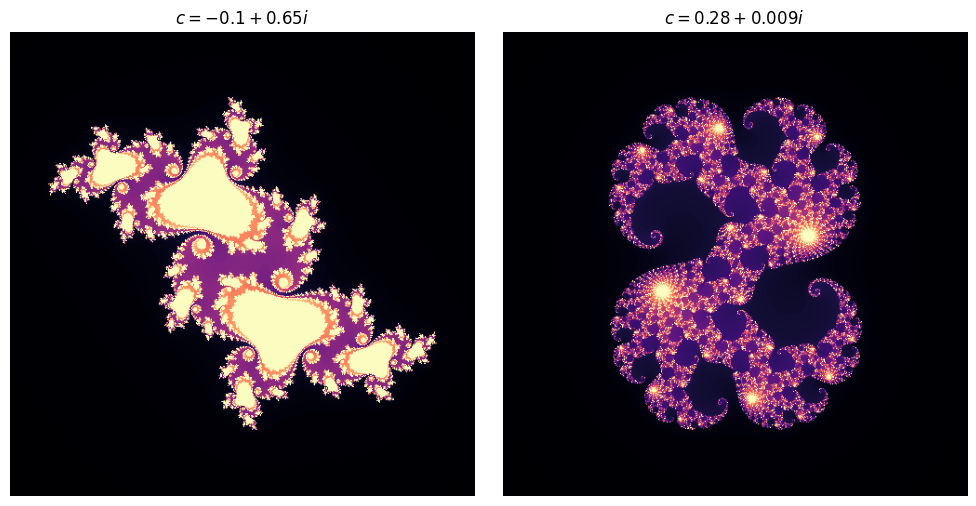

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Функция генерации множества Жюлиа
def plot_julia(c_val, title, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5), res=500, nit=200):
    x = np.linspace(xlim[0], xlim[1], res)
    y = np.linspace(ylim[0], ylim[1], res)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    img = np.zeros(Z.shape)
    
    for i in range(nit):
        mask = np.abs(Z) <= 10
        Z[mask] = Z[mask]**2 + c_val
        img[mask] += 1
        
    plt.imshow(img, extent=[xlim[0], xlim[1], ylim[0], ylim[1]], cmap='magma', origin='lower')
    plt.title(title)
    plt.axis('off')

# 2. Отрисовка двух фракталов из условия
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plot_julia(-0.1 + 0.65j, r'$c = -0.1 + 0.65i$')

plt.subplot(1, 2, 2)
plot_julia(0.28 + 0.009j, r'$c = 0.28 + 0.009i$')

plt.tight_layout()
plt.show()

**2.10\*** Изображение на сфере Римана (стереографическая проекция) кривых и логарифмической спирали $r = a e^{b\phi}$.

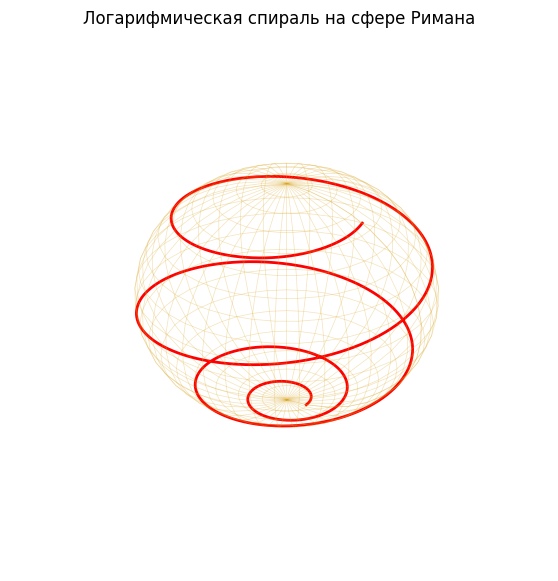

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Стереографическая проекция точки плоскости (x, y) на сферу Римана (xi, eta, zeta)
def to_riemann(x, y):
    d = x**2 + y**2 + 1
    return 2*x/d, 2*y/d, (x**2 + y**2 - 1)/d

# 2. Логарифмическая спираль r = a * exp(b * phi)
phi = np.linspace(-4*np.pi, 4*np.pi, 2000)
r = 0.5 * np.exp(0.15 * phi)
x_spiral, y_spiral = r * np.cos(phi), r * np.sin(phi)
xi, eta, zeta = to_riemann(x_spiral, y_spiral)

# 3. 3D визуализация сферы Римана
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Отрисовка прозрачной единичной сферы
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
xs = np.cos(u) * np.sin(v)
ys = np.sin(u) * np.sin(v)
zs = np.cos(v)
ax.plot_wireframe(xs, ys, zs, color="goldenrod", alpha=0.3, linewidth=0.5)

# Траектория спирали на сфере
ax.plot(xi, eta, zeta, color='red', lw=2, label='Логарифмическая спираль')

ax.set_axis_off()
ax.set_title('Логарифмическая спираль на сфере Римана')
plt.show()

# **3 Листок**

**3.1** (Задача о равномерном спуске) Найти такую кривую, что тяжёлая точка под действием силы тяжести равномерно опускается по этой кривой ($v_y = \text{const} = -v_0 < 0$).
1) Вывести дифференциальное уравнение и найти его аналитическое решение $y = f(x)$;
2) Построить статический график найденной кривой;
3) Создать анимацию спуска точки с постоянной вертикальной скоростью.

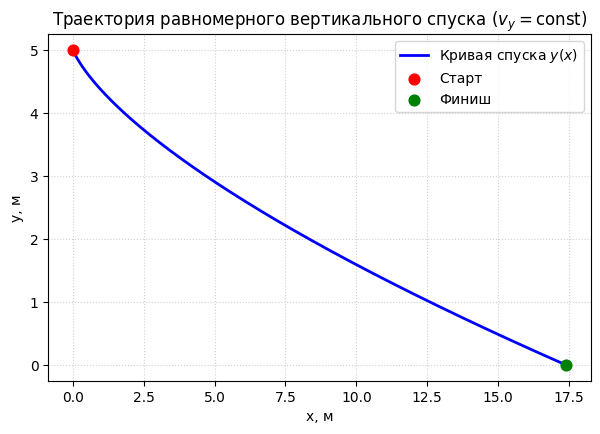

KeyboardInterrupt: 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, Math, HTML

# 1. Параметры задачи
g = 9.81
v0 = 2.0  # постоянная вертикальная скорость спуска |vy|
y0 = 5.0  # начальная высота
t_max = y0 / v0

# 2. Аналитическое решение: полукубическая парабола y = f(x)
# x(t) = ( (v0^2 + 2*g*v0*t)**(1.5) - v0^3 ) / (3 * g * v0)
# y(t) = y0 - v0 * t
t_vals = np.linspace(0, t_max, 300)
x_vals = ((v0**2 + 2 * g * v0 * t_vals)**1.5 - v0**3) / (3 * g * v0)
y_vals = y0 - v0 * t_vals

# 3. Статическая визуализация траектории
plt.figure(figsize=(7, 4.5))
plt.plot(x_vals, y_vals, 'b-', lw=2, label=r'Кривая спуска $y(x)$')
plt.scatter([x_vals[0]], [y_vals[0]], color='red', s=60, zorder=5, label='Старт')
plt.scatter([x_vals[-1]], [y_vals[-1]], color='green', s=60, zorder=5, label='Финиш')
plt.title(r'Траектория равномерного вертикального спуска ($v_y = \mathrm{const}$)')
plt.xlabel('x, м')
plt.ylabel('y, м')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig('descent_curve.png', dpi=150)
plt.show()

# 4. Анимация движения материальной точки
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_vals, y_vals, 'b--', alpha=0.5)
point, = ax.plot([], [], 'ro', ms=8)
time_text = ax.text(0.05, 0.9, '', transform=ax.transAxes)
ax.set_xlim(-0.5, x_vals[-1] + 1)
ax.set_ylim(-0.5, y0 + 0.5)
ax.grid(True, linestyle=':')

def init():
    point.set_data([], [])
    time_text.set_text('')
    return point, time_text

def update(frame):
    point.set_data([x_vals[frame]], [y_vals[frame]])
    time_text.set_text(f't = {t_vals[frame]:.2f} c, vy = -{v0:.1f} м/с')
    return point, time_text

anim = FuncAnimation(fig, update, frames=len(t_vals), init_func=init, blit=True, interval=30)
plt.close(fig)
display(HTML(anim.to_jshtml()))

**3.2** (Задача о бильярде в прямоугольнике) Изучение движения материальной точки в прямоугольнике со сторонами $a$ и $b$ с упругими отражениями от границ (периодические и эргодические траектории, метод развёртки).

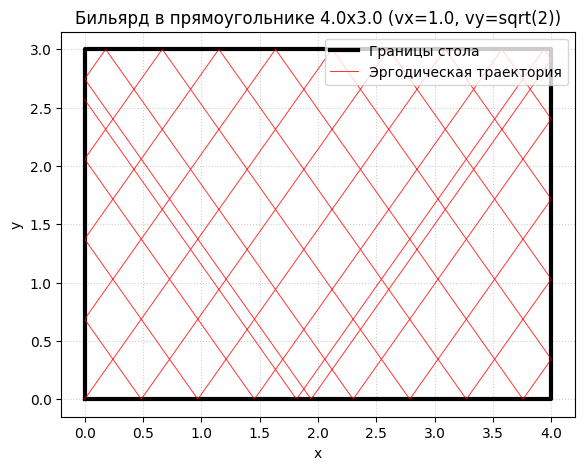

: 

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML

# 1. Параметры бильярдного стола и движения
a, b = 4.0, 3.0
vx, vy = 1.0, np.sqrt(2)  # иррациональное отношение скоростей -> эргодическая траектория
t = np.linspace(0, 40, 2000)

# 2. Метод развертки: отражение через периодическую функцию треугольной волны
def unfold(val, length):
    mod = val % (2 * length)
    return np.where(mod <= length, mod, 2 * length - mod)

x_billiard = unfold(vx * t, a)
y_billiard = unfold(vy * t, b)

# 3. Статическая визуализация
plt.figure(figsize=(7, 5))
plt.plot([0, a, a, 0, 0], [0, 0, b, b, 0], 'k-', lw=3, label='Границы стола')
plt.plot(x_billiard, y_billiard, 'r-', lw=0.7, alpha=0.8, label='Эргодическая траектория')
plt.title(f'Бильярд в прямоугольнике {a}x{b} (vx={vx}, vy=sqrt(2))')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.savefig('billiard.png', dpi=150)
plt.show()

# 4. Анимация движения шара
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, a, a, 0, 0], [0, 0, b, b, 0], 'k-', lw=3)
trail, = ax.plot([], [], 'r-', lw=0.8, alpha=0.6)
ball, = ax.plot([], [], 'bo', ms=9)
ax.set_xlim(-0.2, a + 0.2)
ax.set_ylim(-0.2, b + 0.2)
ax.set_aspect('equal')

def update(frame):
    step = frame * 4
    trail.set_data(x_billiard[:step], y_billiard[:step])
    ball.set_data([x_billiard[step]], [y_billiard[step]])
    return trail, ball

anim_billiard = FuncAnimation(fig, update, frames=len(t)//4, interval=25, blit=True)
plt.close(fig)
display(HTML(anim_billiard.to_jshtml()))

**3.3** (Задача о цепной линии) Исследовать форму равновесия однородной тяжёлой нерастяжимой нити, подвешенной за два конца: $y = a \cosh(x/a)$.

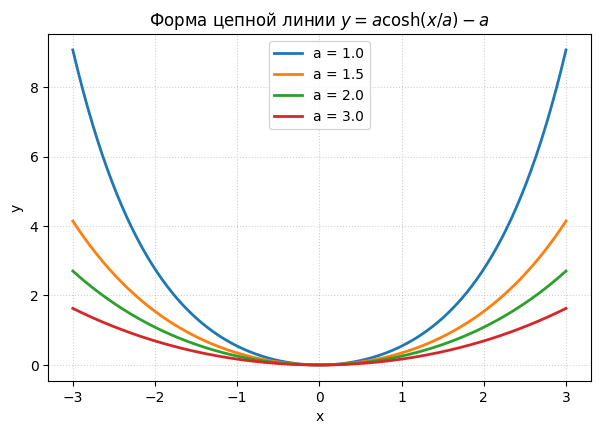

KeyboardInterrupt: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML

# 1. Расчет цепной линии для различных значений параметра a = T0 / (rho * g)
x = np.linspace(-3, 3, 300)
a_values = [1.0, 1.5, 2.0, 3.0]

# 2. Статическая визуализация
plt.figure(figsize=(7, 4.5))
for a in a_values:
    y = a * np.cosh(x / a) - a  # смещаем так, чтобы вершина была в нуле
    plt.plot(x, y, lw=2, label=f'a = {a}')

plt.title(r'Форма цепной линии $y = a\cosh(x/a) - a$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig('catenary.png', dpi=150)
plt.show()

# 3. Анимация провисания нити при изменении параметра натяжения a
fig, ax = plt.subplots(figsize=(7, 4.5))
line, = ax.plot([], [], 'b-', lw=2.5)
ax.set_xlim(-3, 3)
ax.set_ylim(-0.2, 5)
ax.grid(True, linestyle=':')
ax.set_title('Изменение формы цепи при ослаблении натяжения')

a_frames = np.linspace(3.0, 0.8, 60)

def update(frame):
    a = a_frames[frame]
    y = a * np.cosh(x / a) - a
    line.set_data(x, y)
    return line,

anim_catenary = FuncAnimation(fig, update, frames=len(a_frames), interval=50, blit=True)
plt.close(fig)
display(HTML(anim_catenary.to_jshtml()))

**3.4** (Задача о таутохроне) Исследовать свойство изохронности циклоиды: время скатывания точки по перевёрнутой циклоиде до нижней точки не зависит от начальной высоты.


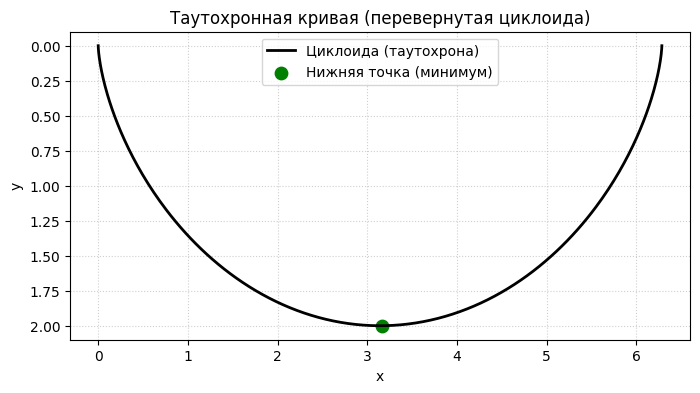

KeyboardInterrupt: 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML

# 1. Параметрическое задание перевернутой циклоиды
R, g = 1.0, 9.81
theta = np.linspace(0, 2 * np.pi, 300)
x_cyc = R * (theta - np.sin(theta))
y_cyc = R * (1 - np.cos(theta))

# 2. Статическая визуализация кривой
plt.figure(figsize=(8, 4))
plt.plot(x_cyc, y_cyc, 'k-', lw=2, label='Циклоида (таутохрона)')
plt.gca().invert_yaxis()  # нижняя точка траектории внизу
plt.scatter([x_cyc[len(x_cyc)//2]], [y_cyc[len(y_cyc)//2]], color='green', s=80, label='Нижняя точка (минимум)')
plt.title('Таутохронная кривая (перевернутая циклоида)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig('tautochrone.png', dpi=150)
plt.show()

# 3. Анимация одновременного скатывания шариков с разных начальных высот
# Уравнение движения вдоль дуги циклоиды: d^2(s)/dt^2 + (g / 4R) * s = 0 (гармонический осциллятор!)
omega = np.sqrt(g / (4 * R))
t_arr = np.linspace(0, np.pi / (2 * omega), 80)

# Три начальных угла отклонения
theta0_list = [np.pi * 0.4, np.pi * 0.7, np.pi * 0.95]
colors = ['red', 'blue', 'orange']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_cyc, y_cyc, 'k-', lw=1.5)
ax.invert_yaxis()
balls = [ax.plot([], [], 'o', color=col, ms=9, label=f'Шарик {i+1}')[0] for i, col in enumerate(colors)]
ax.legend()
ax.grid(True, linestyle=':')
ax.set_title('Изохронный спуск: одновременное прибытие в нижнюю точку')

def update(frame):
    t = t_arr[frame]
    for i, th0 in enumerate(theta0_list):
        # s(t) = s0 * cos(omega * t), для циклоиды s = 4R * cos(theta/2)
        th = np.pi - 2 * np.arcsin(np.sin(th0 / 2) * np.cos(omega * t))
        bx = R * (th - np.sin(th))
        by = R * (1 - np.cos(th))
        balls[i].set_data([bx], [by])
    return balls

anim_tauto = FuncAnimation(fig, update, frames=len(t_arr), interval=40, blit=True)
plt.close(fig)
display(HTML(anim_tauto.to_jshtml()))

**3.5** (Движение математического маятника) Исследовать нелинейные колебания математического маятника $\ddot{\theta} + \omega_0^2 \sin\theta = 0$, построить фазовый портрет с сепаратрисой и анимацию.


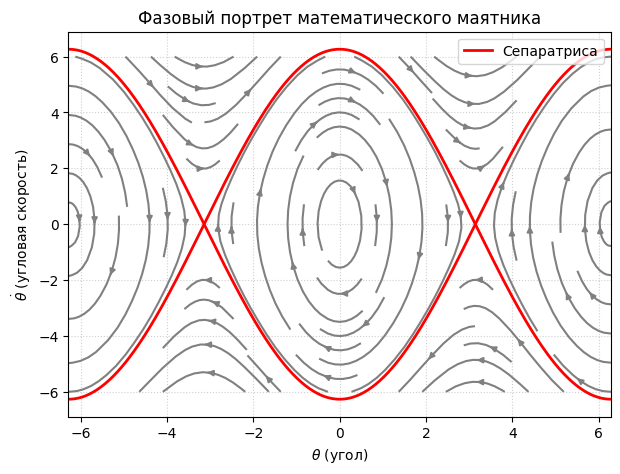

: 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML

# 1. Уравнение движения маятника: d/dt [theta, omega] = [omega, -g/L * sin(theta)]
g, L = 9.81, 1.0
omega0_sq = g / L

def pendulum_deriv(state, t):
    theta, omega = state
    return [omega, -omega0_sq * np.sin(theta)]

# 2. Фазовый портрет (статический)
plt.figure(figsize=(7, 5))
th_grid, om_grid = np.meshgrid(np.linspace(-2*np.pi, 2*np.pi, 20), np.linspace(-6, 6, 20))
d_th = om_grid
d_om = -omega0_sq * np.sin(th_grid)
plt.streamplot(th_grid, om_grid, d_th, d_om, color='gray', density=0.8, arrowsize=0.8)

# Построение сепаратрисы E = 2 * omega0^2 (разделяющей колебания и вращения)
th_dense = np.linspace(-2*np.pi, 2*np.pi, 400)
sep_omega = 2 * np.sqrt(omega0_sq) * np.cos(th_dense / 2)
plt.plot(th_dense, sep_omega, 'r-', lw=2, label='Сепаратриса')
plt.plot(th_dense, -sep_omega, 'r-', lw=2)

plt.title('Фазовый портрет математического маятника')
plt.xlabel(r'$\theta$ (угол)')
plt.ylabel(r'$\dot{\theta}$ (угловая скорость)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig('pendulum_phase.png', dpi=150)
plt.show()

# 3. Анимация движения маятника в пространстве
t_sim = np.linspace(0, 5, 200)
theta_sol = odeint(pendulum_deriv, [np.pi * 0.7, 0.0], t_sim)[:, 0]
x_pend = L * np.sin(theta_sol)
y_pend = -L * np.cos(theta_sol)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(-1.2*L, 1.2*L)
ax.set_ylim(-1.2*L, 0.2*L)
ax.set_aspect('equal')
ax.grid(True, linestyle=':')
ax.plot(0, 0, 'ks', ms=6)  # точка подвеса
rod, = ax.plot([], [], 'k-', lw=2)
bob, = ax.plot([], [], 'ro', ms=14)

def update(frame):
    rod.set_data([0, x_pend[frame]], [0, y_pend[frame]])
    bob.set_data([x_pend[frame]], [y_pend[frame]])
    return rod, bob

anim_pendulum = FuncAnimation(fig, update, frames=len(t_sim), interval=25, blit=True)
plt.close(fig)
display(HTML(anim_pendulum.to_jshtml()))